# Part I: 1D Black Scholes Case

In [12]:
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt

from bsde_cfft_sv import BSDECFFT1D, bs_call_price, bs_call_delta, HestonBSDECFFT, GARCHDiffusionBSDECFFT
from bsde_cfft_sv._benchmarks import heston_call_price, heston_mc_milstein, garch_diffusion_pyfeng_price

In [3]:
S0, K, r, sigma, T = 100.0, 100.0, 0.01, 0.2, 1.0
L, n_steps, alpha = 10.0, 1000, -3.0

price_bs = bs_call_price(S0, K, r, sigma, T)
delta_bs = bs_call_delta(S0, K, r, sigma, T)

row_bs = []
for N in [1024,2048, 4096, 8192]:
    t0 = time.time()
    solver = BSDECFFT1D(r=r, mu=r, sigma=sigma, K=K, T=T, L=L, N=N, n_steps=n_steps, alpha=alpha)
    elapse = time.time() - t0
    price, delta = solver.price_at(S0)
    row_bs.append({
        "N": N,
        "price": price,
        "delta": delta,
        "time": elapse,
        "abs_price_error": abs(price_bs - price),
        "abs_delta_error": abs(delta_bs - delta)
    })

print("Analytical Price", price_bs)
print("Analytical Delta", delta_bs)
df = pd.DataFrame(row_bs)
df

Analytical Price 8.433318690109608
Analytical Delta 0.5596176923702425


,N,price,delta,time,abs_price_error,abs_delta_error
0,1024,8.431795,0.559619,0.000139,0.001524,0.000001
1,2048,8.432926,0.559623,0.000211,0.000392,0.000005
2,4096,8.433220,0.559623,0.000323,0.000098,0.000006
3,8192,8.433294,0.559623,0.000770,0.000025,0.000006


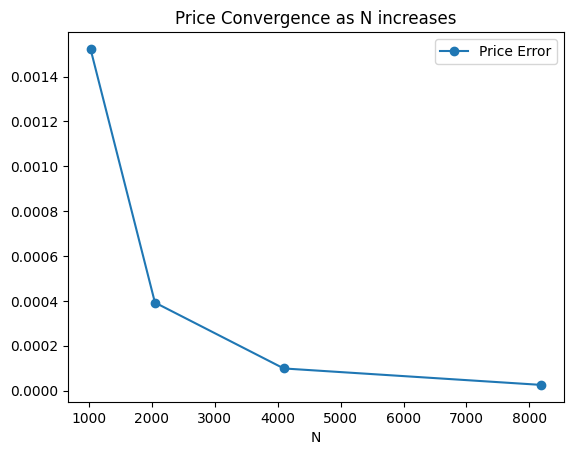

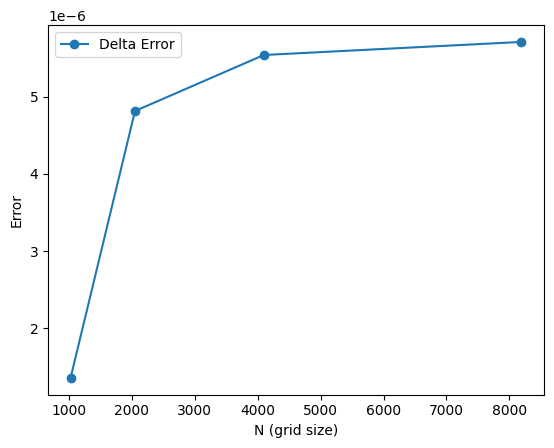

In [5]:




df.plot(x="N", y="abs_price_error", marker='o', label="Price Error")
plt.title("Price Convergence as N increases")
df.plot(x="N", y="abs_delta_error", marker='o', label="Delta Error")

plt.xlabel("N (grid size)")
plt.ylabel("Error")
plt.legend()
plt.show()

## Changing L Truncation Error

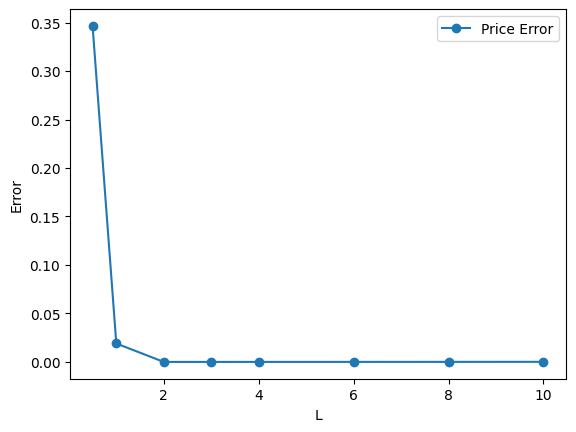

In [22]:
N = 4096

row_bs_L = []
for L in [0.5, 1, 2, 3, 4, 6, 8, 10]:
    t0 = time.time()
    solver = BSDECFFT1D(r=r, mu=r, sigma=sigma, K=K, T=T, L=L, N=N, n_steps=n_steps, alpha=alpha)
    elapse = time.time() - t0
    price, delta = solver.price_at(S0)
    row_bs_L.append({
        "L": L,
        "price": price,
        "delta": delta,
        "time": elapse,
        "abs_price_error": abs(price_bs - price),
        "abs_delta_error": abs(delta_bs - delta)
    })

import matplotlib.pyplot as plt

df_L = pd.DataFrame(row_bs_L)

df_L.plot(x="L", y="abs_price_error", marker='o', label="Price Error")

plt.xlabel("L")
plt.ylabel("Error")
plt.legend()
plt.show()

For small L, truncation error dominates because the log-price domain is too narrow.
Beyond a threshold (around L≈3), the domain is sufficiently large and truncation error becomes negligible relative to discretization error.

# Part II: 2D Heston Benchmark

In [25]:
S0, K = 100.0, 100.0
r = 0.05
kappa, theta, xi, rho, V0, T = 2.0, 0.04, 0.3, -0.7, 0.04, 1.0

ref_price = heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_mc_price, heston_mc_se = heston_mc_milstein(S0, K, r, kappa, theta, xi, rho, V0, T, n_paths=100000, n_steps=500)


# Different grid sizes to test
configs = [
    (32, 16),
    (64, 32),
    (96, 48),
    (128, 64),
    (160, 80),
]

rows = []

for Nx, Nv in configs:
    start = time.time()

    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T,
        Nx=Nx, Nv=Nv,
        Lx=10.0, Lv=0.25,
        n_steps=500,
        v_center=V0,
        alpha_x=-3.0,
    )

    price, _, _, _ = solver.price_delta_z_at(S0, V0)

    elapsed = time.time() - start

    rows.append({
        "price": price,
        "grid_points": Nx * Nv,
        "error": abs(price - ref_price),
        "time": elapsed
    })

df = pd.DataFrame(rows)

In [21]:
df

,price,grid_points,error,time
0,8.651154,512,1.743065,0.109255
1,10.243828,2048,0.150391,0.467208
2,10.343438,4608,0.050781,1.400444
3,10.368312,8192,0.025907,2.842204
4,10.378931,12800,0.015288,5.572718


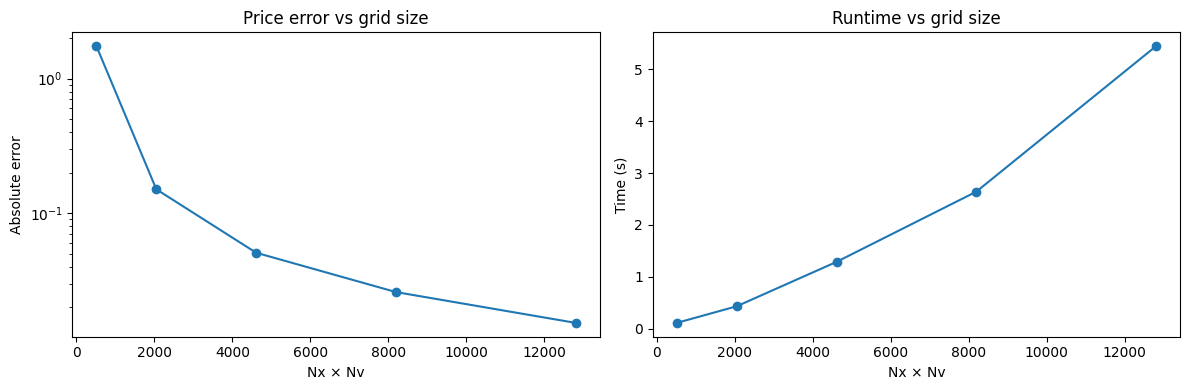

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Error vs grid size
axes[0].plot(df["grid_points"], df["error"], marker="o")
axes[0].set_title("Price error vs grid size")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute error")
axes[0].set_yscale("log")

# Time vs grid size
axes[1].plot(df["grid_points"], df["time"], marker="o")
axes[1].set_title("Runtime vs grid size")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Time (s)")

plt.tight_layout()
plt.show()

The numerical method converges to the true solution as grid resolution increases, and here is the accuracy vs cost tradeoff

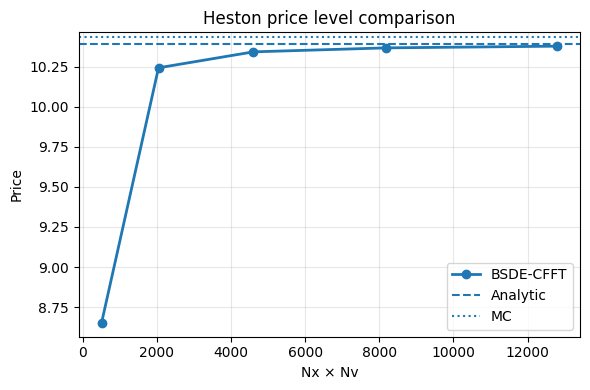

In [27]:
plt.figure(figsize=(6, 4))

plt.plot(df["grid_points"], df["price"], marker="o", linewidth=2, label="BSDE-CFFT")
plt.axhline(ref_price, linestyle="--", label="Analytic")
plt.axhline(heston_mc_price, linestyle=":", label="MC")

plt.title("Heston price level comparison")
plt.xlabel("Nx × Nv")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Part III: 2D GARCH Diffusion 

In [3]:
S0, K = 100.0, 100.0
r, mu, a, b, c, V0, T = 0.05, 0.05, 2.0, 0.04, 0.4, 0.04, 1.0

# Use ONE reference (just fix a high-resolution solution)
ref_solver = GARCHDiffusionBSDECFFT(
    r=r, mu=mu, a=a, b=b, c=c, rho=0.0,
    K=K, T=T, Nx=160, Nv=80, Lx=10.0, Lv=0.32,
    n_steps=1100, v_center=V0, alpha_x=-3.0,
)
ref_price, _, _, _ = ref_solver.price_delta_z_at(S0, V0)

# Grid sizes to test
configs = [
    (32, 16),
    (64, 32),
    (96, 48),
    (128, 64),
    (160, 80),
]

rows = []

for Nx, Nv in configs:
    t0 = time.time()
    
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=0.0,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=0.32,
        n_steps=700, v_center=V0, alpha_x=-3.0,
    )
    
    price, _, _, _ = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0

    rows.append({
        "grid_points": Nx * Nv,
        "abs_price_error": abs(price - ref_price),
        "time_s": elapsed,
    })

df = pd.DataFrame(rows)

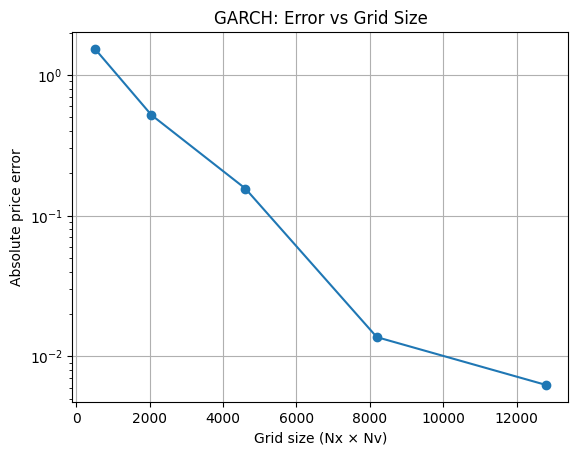

In [6]:
plt.plot(df["grid_points"], df["abs_price_error"], marker="o")
plt.yscale("log")
plt.xlabel("Grid size (Nx × Nv)")
plt.ylabel("Absolute price error")
plt.title("GARCH: Error vs Grid Size")
plt.grid(True)
plt.show()

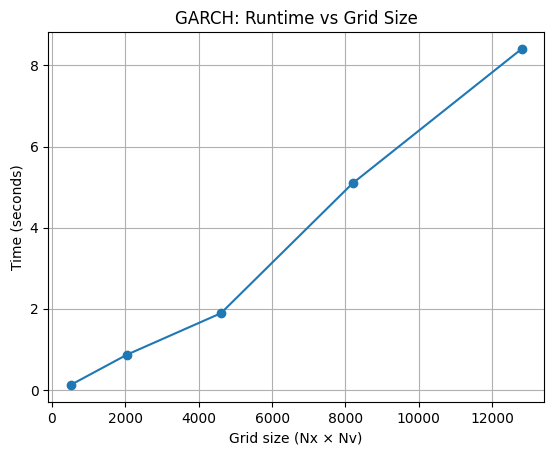

In [7]:
plt.plot(df["grid_points"], df["time_s"], marker="o")
plt.xlabel("Grid size (Nx × Nv)")
plt.ylabel("Time (seconds)")
plt.title("GARCH: Runtime vs Grid Size")
plt.grid(True)
plt.show()

# Part IV: Sensitivity Analysis

In [8]:
def run_sensitivity(param_name, values, solver_builder, ref_price):
    rows = []
    
    for val in values:
        t0 = time.time()
        
        solver = solver_builder(val)
        price, _ = solver.price_at(S0, V0)
        
        rows.append({
            param_name: val,
            "price": price,
            "abs_price_error": abs(price - ref_price),
            "time_s": time.time() - t0
        })
    
    return pd.DataFrame(rows)

In [17]:
S0, K, r, V0, T = 100.0, 100.0, 0.05, 0.04, 1.0
kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
rho0 = 0.0

lv_df = run_sensitivity(
    "Lv",
    [0.15, 0.20, 0.25, 0.30, 0.40],
    lambda Lv: HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=Lv,
        n_steps=700, v_center=V0, alpha_x=-3.0,
    ),
    heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
)

boundary_df = run_sensitivity(
    "v_boundary",
    ["none", "neumann"],
    lambda vb: HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.20,
        n_steps=700, v_center=V0, alpha_x=-3.0,
        v_boundary=vb,
    ),
   heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
)



alpha_df = run_sensitivity(
    "alpha_x",
    [-2.5, -3.0, -3.5],
    lambda alpha_x: GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho0,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.32,
        n_steps=700, v_center=V0, alpha_x=alpha_x,
    ),
    garch_diffusion_pyfeng_price(S0, K, r, a, b, c, V0, T)
)

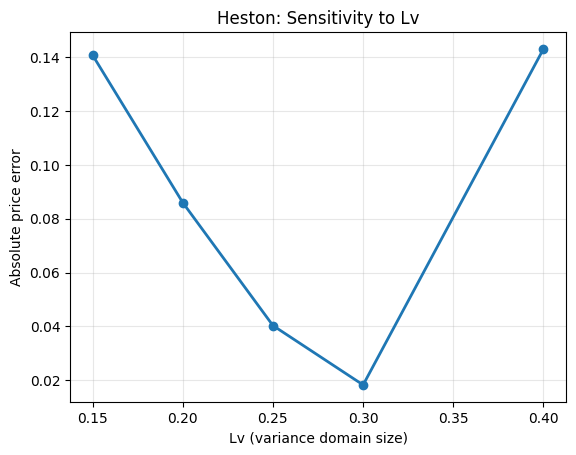

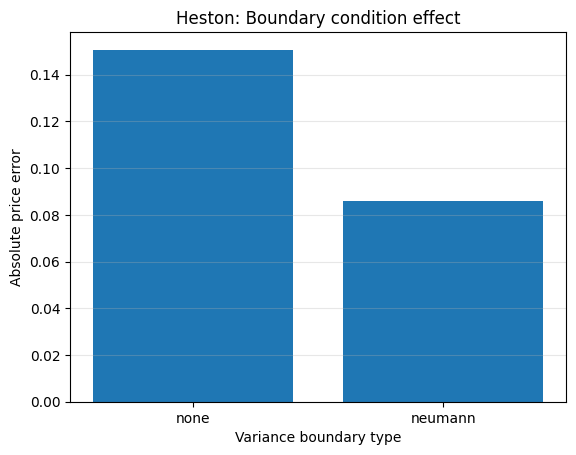

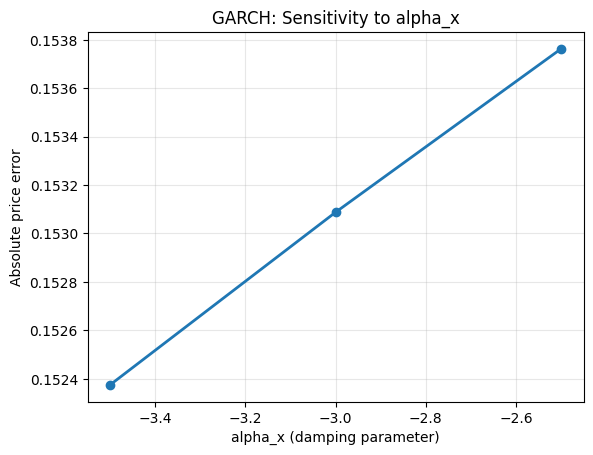

In [18]:
import matplotlib.pyplot as plt

# --- Lv sensitivity ---
plt.figure()
plt.plot(lv_df["Lv"], lv_df["abs_price_error"], marker="o", linewidth=2)
plt.title("Heston: Sensitivity to Lv")
plt.xlabel("Lv (variance domain size)")
plt.ylabel("Absolute price error")
plt.grid(True, alpha=0.3)
plt.show()


# --- Boundary condition sensitivity ---
plt.figure()
plt.bar(boundary_df["v_boundary"], boundary_df["abs_price_error"])
plt.title("Heston: Boundary condition effect")
plt.xlabel("Variance boundary type")
plt.ylabel("Absolute price error")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


# --- Alpha sensitivity ---
plt.figure()
plt.plot(alpha_df["alpha_x"], alpha_df["abs_price_error"], marker="o", linewidth=2)
plt.title("GARCH: Sensitivity to alpha_x")
plt.xlabel("alpha_x (damping parameter)")
plt.ylabel("Absolute price error")
plt.grid(True, alpha=0.3)
plt.show()

## Brief Observations

The results show that increasing the grid size improves pricing accuracy, as the absolute error decreases steadily with (N). This is consistent with convergence of the numerical scheme.

The truncation parameter (L) also affects accuracy: values that are too small introduce truncation error, while overly large values can reduce efficiency without improving results. An intermediate choice provides the best balance.

Disclosure: 

AI tools were used to assist with code simplification, debugging, and clarifying concepts. The implementation is based on a shared team template, which I adapted and explored independently. I used AI to help structure parts of the explanation, while ensuring I understood and verified the results and conclusions myself.